In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import fsolve
from functools import partial
from matplotlib.lines import Line2D 
from pathlib import Path

In [46]:
b_fpv_list = [round(x, 2) for x in np.arange(0.55, .99, 0.1)]
a_fpv_list = [round(x, 2) for x in np.arange(0.55, .99, 0.1)]
b_prop_list = [x/100 for x in range(5, 100, 10)]

generators=["slate-CS-C", "slate-CS-W", "slate-BT", "slate-PL"]
colors= {"slate-CS-C":'#1560BD',
        "slate-CS-W":'#FB607F',
         "slate-BT":'#8DB600',
         "slate-PL":'#FFBF00'}

types_dirichlet=["UU", "UX", "XXsame", "XXdif"]

dirichlet_relabel = {"UU":"Strength Scenario 1", 
"UX":"Strength Scenario 2", 
"XXsame":"Strength Scenario 3",
"XXdif":"Strength Scenario 4",}

dirichlet_markers = {"UU":"o", 
"UX":"v", 
"XXsame":"^",
"XXdif":"s",}

# Dirichlet


In [4]:
N_TRIALS = 100
N_BALLOTS = 5000
N_SEATS = 5
N_CANDS_PER_BLOC = 5

uniform_dirichlet = 2.0
strong_dirichlet = .5

# election_path_name = f'/cluster/tufts/mggg/cdonna01/PRVTP_feb_25_submission/run_elections/election_results/2_bloc/dirichlet'
election_path_name = f'/Users/cdonnay/Documents/GitHub/MGGG/PRVTP/Disprop/run_elections/election_results/2_bloc/dirichlet'

In [17]:
b_fpv_list = [round(x, 2) for x in np.arange(0.55, .99, 0.1)]
a_fpv_list = [round(x, 2) for x in np.arange(0.55, .99, 0.1)]
b_prop_list = [x/100 for x in range(5, 100, 10)]


dirichlet_dfs = {}
failed = []
i=0
for b_prop in b_prop_list:
    for g in generators:
        for cand_strength in types_dirichlet:
            for fpv_b in b_fpv_list:
                for fpv_a in a_fpv_list:
                    try:
                        i+=1
                        sub_path_name = f"seats_{N_SEATS}/cperbloc_{N_CANDS_PER_BLOC}/trials_{N_TRIALS}/ballots_{N_BALLOTS}/fpv_b_{fpv_b}/fpv_a_{fpv_a}/b_prop_{b_prop}/{g}/pi_type_{cand_strength}/dunif_{uniform_dirichlet}/dstrong_{strong_dirichlet}/"
                        file_name = f"seats_{N_SEATS}_cperbloc_{N_CANDS_PER_BLOC}_trials_{N_TRIALS}_ballots_{N_BALLOTS}_fpv_b_{fpv_b}_fpv_a_{fpv_a}_b_prop_{b_prop}_{g}_pi_type_{cand_strength}_dunif_{uniform_dirichlet}_dstrong_{strong_dirichlet}"
                        df = pd.read_csv(f"{election_path_name}/{sub_path_name}/{file_name}.csv")
                        dirichlet_dfs[(fpv_b, fpv_a, b_prop,g, cand_strength)] = df
                    except Exception as e:
                        print(e)
                        print((fpv_b, fpv_a, b_prop, g, cand_strength),"\n")
                        failed.append((fpv_b, fpv_a, b_prop, g, cand_strength))

In [6]:
for x in failed:
    print(f"'{x[0]} {x[1]} {x[2]} {x[3]} {x[4]}' \\")

# With Strength Scenarios

Average S-C -0.02
Average |S-C| 0.08
Average S-C -0.01
Average |S-C| 0.14


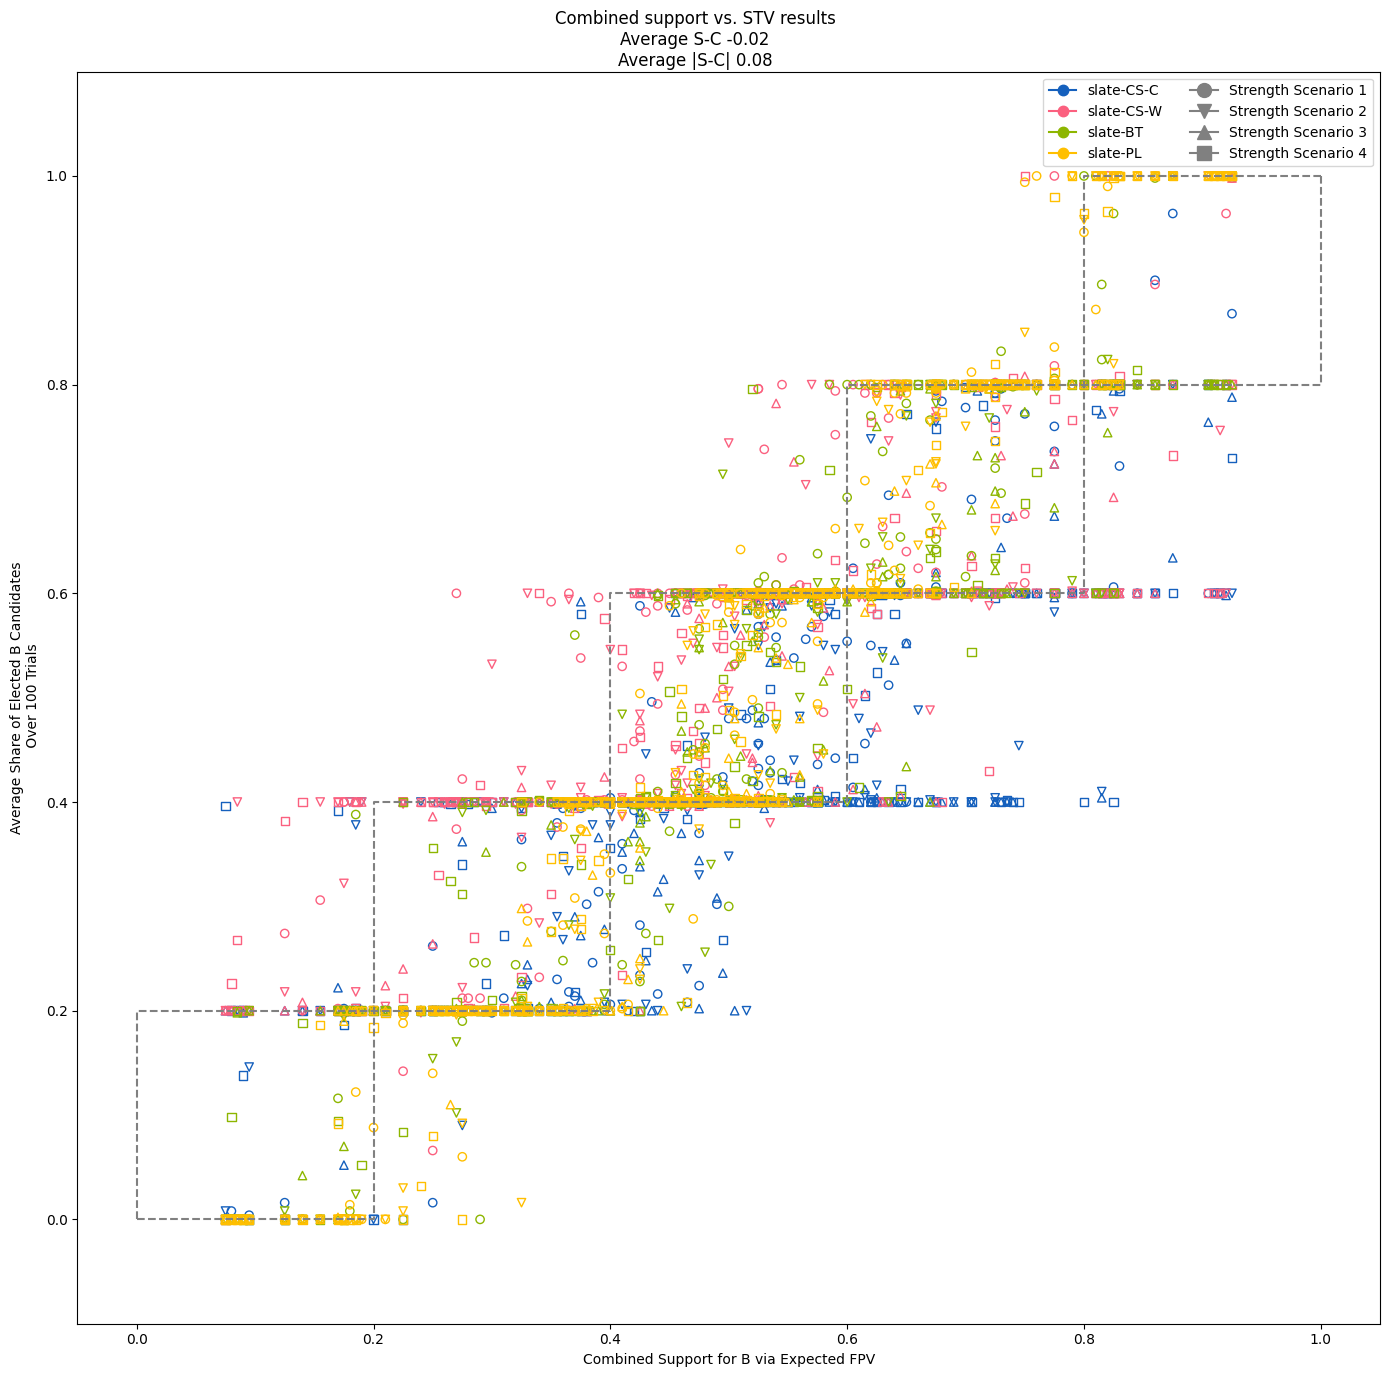

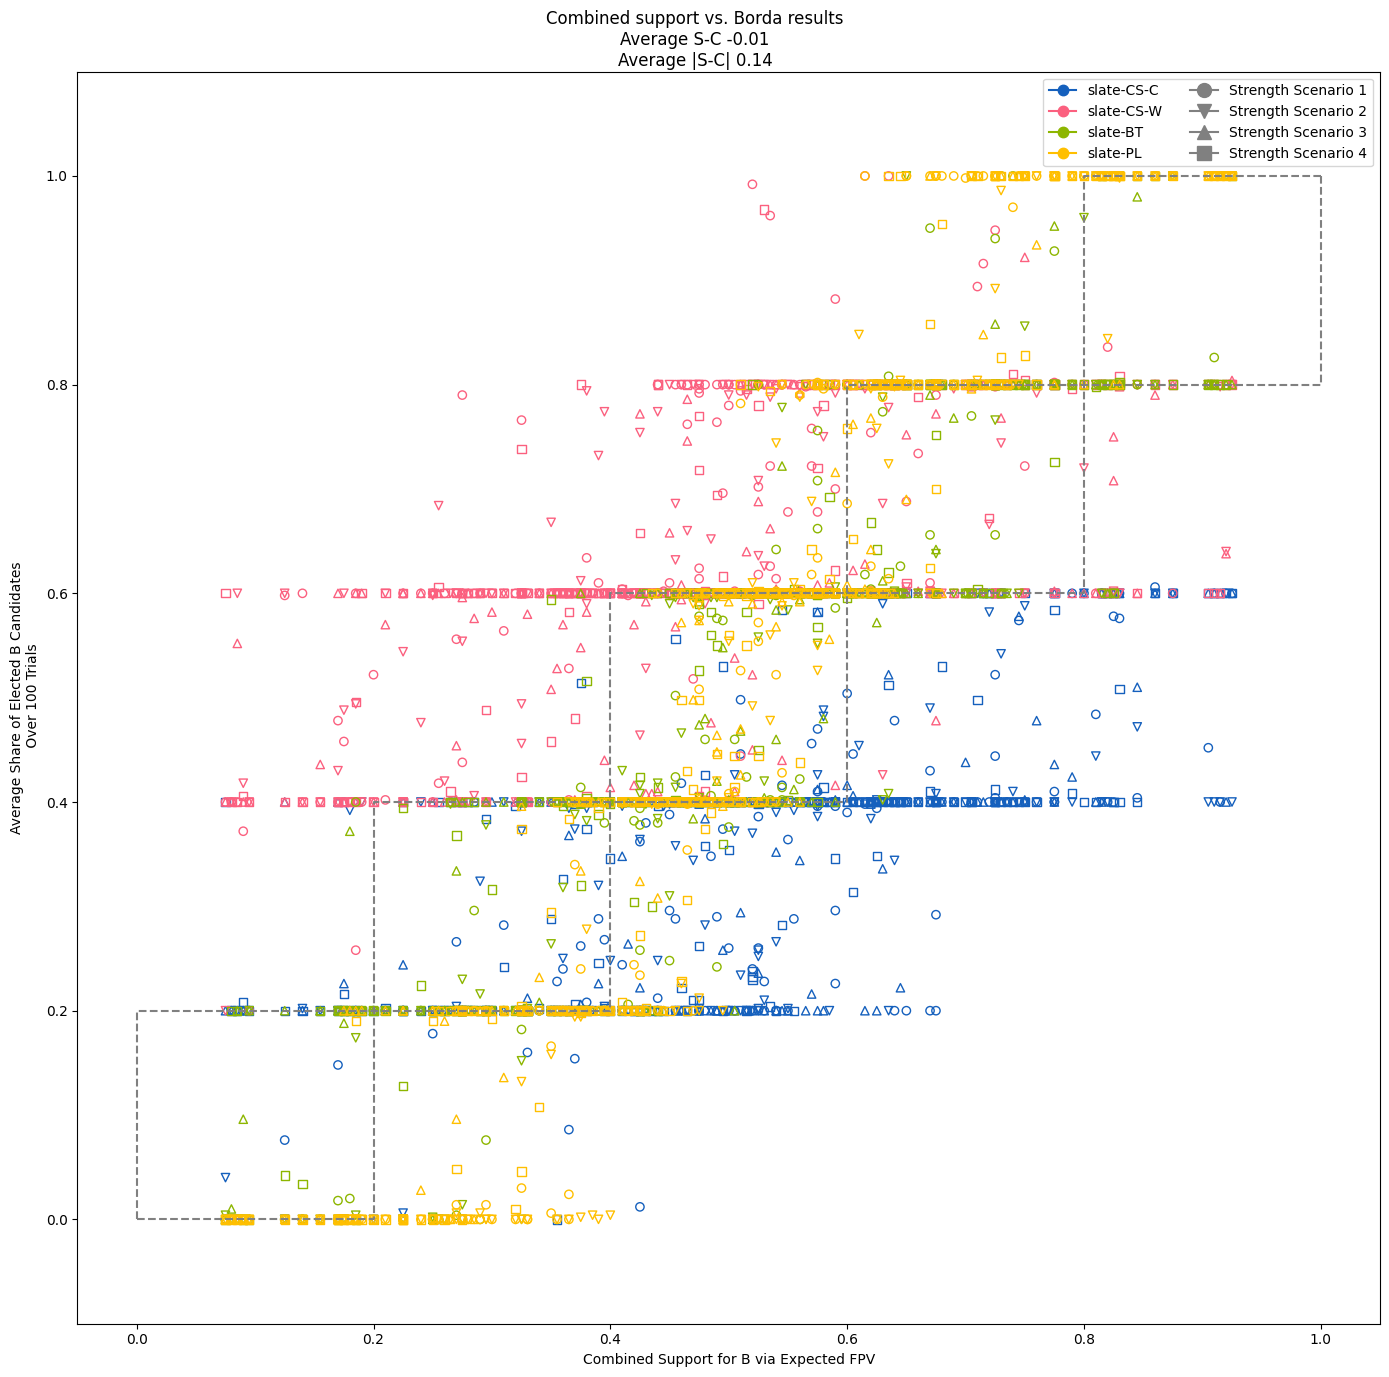

In [48]:
b_fpv_list = [round(x, 2) for x in np.arange(0.55, .99, 0.1)]
a_fpv_list = [round(x, 2) for x in np.arange(0.55, .99, 0.1)]
b_prop_list = [x/100 for x in range(5, 100, 10)]


for election_type in ["stv", "borda"]:
    STAT = "Expected FPV"

    fig, ax = plt.subplots(figsize=(14,14))
    ax.step(
        np.linspace(0,1,N_SEATS+1),
        np.arange(0,1.1, 1/N_SEATS),
        linestyle = 'dashed',
        c='gray',
        where='pre'
    )
    ax.step(
        np.linspace(0,1,N_SEATS+1),
        np.arange(0,1.1, 1/N_SEATS),
        linestyle = 'dashed',
        c='gray',
        where='post'
    )
    ax.set_ylabel(f'Average Share of Elected B Candidates\n Over {N_TRIALS} Trials')
    ax.set_xlabel(f'Combined Support for B via {STAT}')

    data  = [-1]* len(generators)*len(b_prop_list)*len(types_dirichlet)*len(b_fpv_list)*len(a_fpv_list)
    i=0
    for g in generators:
        for b_prop in b_prop_list:
            for cand_strength in types_dirichlet:
                for b_fpv in b_fpv_list:
                    for a_fpv in a_fpv_list:
                        df = dirichlet_dfs[(b_fpv, a_fpv, b_prop, g, cand_strength)]
                        
                        # combined support
                        x = b_fpv*b_prop  + (1-a_fpv)*(1-b_prop)
                        
                        # average seats over trials
                        y = df[f"avg B cands elected {election_type}"].iloc[0]/N_SEATS 
                        ax.scatter(x, y,
                                    label=g,
                                    marker = dirichlet_markers[cand_strength],
                                    edgecolor=colors[g], 
                                    facecolor='none', 
                                    #color = colors[g],
                                    #alpha=.5
                                )
                        data[i]=(x,y)
                        i+=1
                        
    avg_sc = sum(y-x for (x,y) in data)/len(data)
    avg_abs_sc = sum(abs(y-x) for (x,y) in data)/len(data)
    print(f"Average S-C {avg_sc:.2f}")
    print(f"Average |S-C| {avg_abs_sc:.2f}")


    legend_elements = [
        Line2D([0], [0], marker='.', color=colors[g], label=g, markersize=15)
        for g in generators
    ] + [Line2D([0], [0], marker=dirichlet_markers[cand_strength], color="grey", label=dirichlet_relabel[cand_strength], markersize=10)
        for cand_strength in types_dirichlet] 
    # legend_elements = [
    #     Line2D([0], [0], marker='.', color=colors[g], label=g, markersize=15, 
    #            #alpha = .5,
    #            )
    #     for g in generators
    # ] 


    plt.ylim(-.1, 1.1)
    plt.legend(handles=legend_elements, ncol=2)
    if election_type == "stv":
        election_type = election_type.upper()
    else:
        election_type = election_type.capitalize()

    plt.suptitle(f"Combined support vs. {election_type} results\nAverage S-C {avg_sc:.2f}\nAverage |S-C| {avg_abs_sc:.2f}")
    plt.tight_layout()
    # plt.show()

    # path_name = f"/cluster/tufts/mggg/cdonna01/PRVTP_feb_25_submission/deg_of_prop/figures/{N_SEATS}_seats/{STAT}_combined_support/all_models/{election_type}"
    path_name = f"/Users/cdonnay/Documents/GitHub/MGGG/PRVTP/Disprop/deg_of_prop/figures/{N_SEATS}_seats/{STAT}_combined_support/all_models/{election_type}"

    file_name = f"WITH_STRENGTH_{N_SEATS}_seats_combined_support_{election_type}.png"
    path = Path(path_name)

    plt.savefig(f"{path_name}/{file_name}", dpi=300)


## Without strength

In [ ]:
b_fpv_list = [round(x, 2) for x in np.arange(0.55, .99, 0.1)]
a_fpv_list = [round(x, 2) for x in np.arange(0.55, .99, 0.1)]
b_prop_list = [x/100 for x in range(5, 100, 10)]


for election_type in ["stv", "borda"]:
    STAT = "Expected FPV"

    fig, ax = plt.subplots(figsize=(14,14))
    ax.step(
        np.linspace(0,1,N_SEATS+1),
        np.arange(0,1.1, 1/N_SEATS),
        linestyle = 'dashed',
        c='gray',
        where='pre'
    )
    ax.step(
        np.linspace(0,1,N_SEATS+1),
        np.arange(0,1.1, 1/N_SEATS),
        linestyle = 'dashed',
        c='gray',
        where='post'
    )
    ax.set_ylabel(f'Average Share of Elected B Candidates\n Over {N_TRIALS} Trials')
    ax.set_xlabel(f'Combined Support for B via {STAT}')

    data  = [-1]* len(generators)*len(b_prop_list)*len(types_dirichlet)*len(b_fpv_list)*len(a_fpv_list)
    i=0
    for g in generators:
        for b_prop in b_prop_list:
            for cand_strength in types_dirichlet:
                for b_fpv in b_fpv_list:
                    for a_fpv in a_fpv_list:
                        df = dirichlet_dfs[(b_fpv, a_fpv, b_prop, g, cand_strength)]
                        
                        # combined support
                        x = b_fpv*b_prop  + (1-a_fpv)*(1-b_prop)
                        
                        # average seats over trials
                        y = df[f"avg B cands elected {election_type}"].iloc[0]/N_SEATS 
                        ax.scatter(x, y,
                                    label=g,
                                    #marker = dirichlet_markers[cand_strength],
                                    #edgecolor=colors[g], 
                                    #facecolor='none', 
                                    color = colors[g],
                                    alpha=.5
                                )
                        data[i]=(x,y)
                        i+=1
                        
    avg_sc = sum(y-x for (x,y) in data)/len(data)
    avg_abs_sc = sum(abs(y-x) for (x,y) in data)/len(data)
    print(f"Average S-C {avg_sc:.2f}")
    print(f"Average |S-C| {avg_abs_sc:.2f}")


    # legend_elements = [
    #     Line2D([0], [0], marker='.', color=colors[g], label=g, markersize=15)
    #     for g in generators
    # ] + [Line2D([0], [0], marker=dirichlet_markers[cand_strength], color="grey", label=dirichlet_relabel[cand_strength], markersize=10)
    #     for cand_strength in types_dirichlet] 
    legend_elements = [
        Line2D([0], [0], marker='.', color=colors[g], label=g, markersize=15, 
               alpha = .5,
               )
        for g in generators
    ] 


    plt.ylim(-.1, 1.1)
    plt.legend(handles=legend_elements, ncol=2)
    if election_type == "stv":
        election_type = election_type.upper()
    else:
        election_type = election_type.capitalize()

    plt.suptitle(f"Combined support vs. {election_type} results\nAverage S-C {avg_sc:.2f}\nAverage |S-C| {avg_abs_sc:.2f}")
    plt.tight_layout()
    # plt.show()

    # path_name = f"/cluster/tufts/mggg/cdonna01/PRVTP_feb_25_submission/deg_of_prop/figures/{N_SEATS}_seats/{STAT}_combined_support/all_models/{election_type}"
    path_name = f"/Users/cdonnay/Documents/GitHub/MGGG/PRVTP/Disprop/deg_of_prop/figures/{N_SEATS}_seats/{STAT}_combined_support/all_models/{election_type}"

    file_name = f"WITHOUT_STRENGTH_{N_SEATS}_seats_combined_support_{election_type}.png"
    path = Path(path_name)

    plt.savefig(f"{path_name}/{file_name}", dpi=300)


Average S-C -0.02
Average |S-C| 0.08


# Degree by Parameter

In [37]:
degrees = {"generator":[],
            "cand_strength":[],
            "cohesion":[],
            "Average S-C stv":[],
            "Average S-C borda":[],
            "Average |S-C| stv": [],
            "Average |S-C| borda": [],
            }


STAT = "Expected FPV"


for g in generators:
    for cand_strength in types_dirichlet:
        for cohesion in ["full", "polarized"]:
            degrees["generator"].append(g)
            degrees["cand_strength"].append(cand_strength)
            degrees["cohesion"].append(cohesion)
            for election_type in ["stv", "borda"]:
                print("\n",election_type, g, cand_strength, f"cohesion {cohesion}")

                if cohesion == "full":
                    b_coh_list = [round(x, 2) for x in np.arange(0.55, .99, 0.1)]
                    a_coh_list = [round(x, 2) for x in np.arange(0.55, .99, 0.1)]
                else:
                    b_coh_list = [round(x, 2) for x in np.arange(0.75, .99, 0.1)]
                    a_coh_list = [round(x, 2) for x in np.arange(0.75, .99, 0.1)]


                b_prop_list = [x/100 for x in range(5, 100, 10)]

                
                fig, ax = plt.subplots(figsize=(14,14))
                ax.step(
                    np.linspace(0,1,N_SEATS+1),
                    np.arange(0,1.1, 1/N_SEATS),
                    linestyle = 'dashed',
                    c='gray',
                    where='pre'
                )
                ax.step(
                    np.linspace(0,1,N_SEATS+1),
                    np.arange(0,1.1, 1/N_SEATS),
                    linestyle = 'dashed',
                    c='gray',
                    where='post'
                )
                ax.set_ylabel(f'Average Share of Elected B Candidates\n Over {N_TRIALS} Trials')
                ax.set_xlabel(f'Combined Support for B via {STAT}')
            
                data  = []
                for b_prop in b_prop_list:
                    for b_fpv in b_coh_list:
                        for a_fpv in a_coh_list:
                            df = dirichlet_dfs[(b_fpv, a_fpv, b_prop, g, cand_strength)]
                            x = b_fpv*b_prop  + (1-a_fpv)*(1-b_prop)
                            
                            # average seats over trials
                            y = df[f"avg B cands elected {election_type}"].iloc[0]/N_SEATS 

                            data.append((x,y))
                            ax.scatter(x, y,
                                label=g,
                                marker = dirichlet_markers[cand_strength],
                                edgecolor=colors[g], 
                                facecolor=colors[g]
                            )
                
            
                avg_sc = sum(y-x for (x,y) in data)/len(data)
                avg_abs_sc = sum(abs(y-x) for (x,y) in data)/len(data)
                
                degrees[f"Average S-C {election_type}"].append(avg_sc)
                degrees[f"Average |S-C| {election_type}"].append(avg_abs_sc)

                print(f"Average S-C {avg_sc:.2f}")
                print(f"Average |S-C| {avg_abs_sc:.2f}")
                
                legend_elements = [
                    Line2D([0], [0], marker='.', color=colors[g], label=g, markersize=15)
                    for g in [g]
                ] + [Line2D([0], [0], marker=dirichlet_markers[cand_strength], color="grey", label=cand_strength, markersize=10)
                    for cand_strength in [cand_strength]]

                plt.ylim(-.1, 1.1)
                plt.legend(handles=legend_elements)

                plt.suptitle((f"Combined support vs. {election_type.upper() if election_type == 'stv' else election_type.capitalize()} results\n2 bloc profile\n{N_TRIALS} trials, "
                        f"{N_BALLOTS} ballots, {N_SEATS} seats, {N_CANDS_PER_BLOC} candidates per bloc\n"
                        f"pi_B {b_coh_list}\n pi_A {a_coh_list}\n b_prop {b_prop_list}\n Dirichlet"
                            f"\nAverage S-C {avg_sc:.2f}\nAverage |S-C| {avg_abs_sc:.2f}"))



                path_name = f"/cluster/tufts/mggg/cdonna01/PRVTP_feb_25_submission/deg_of_prop/figures/{N_SEATS}_seats/{STAT}_combined_support/{g}/{cand_strength}/{cohesion}/{election_type}"
                file_name = f"{N_SEATS}_seats_{STAT}_combined_support_{election_type}_{g}_{cand_strength}_{cohesion}.png"
                path = Path(path_name)
                # Create the directory
                path.mkdir(parents=True, exist_ok=True)
                plt.tight_layout()
                plt.savefig(f"{path_name}/{file_name}",dpi=300)
                plt.close()


data_frame = pd.DataFrame.from_dict(degrees)
data_frame = data_frame.round(4)
data_frame.to_csv(f"/cluster/tufts/mggg/cdonna01/PRVTP_feb_25_submission/deg_of_prop/data/{N_SEATS}_seats_disprop_2_bloc_{STAT}.csv")


 stv slate-CS-C UU cohesion full
Average S-C -0.06
Average |S-C| 0.08

 borda slate-CS-C UU cohesion full
Average S-C -0.18
Average |S-C| 0.19

 stv slate-CS-C UU cohesion polarized
Average S-C -0.05
Average |S-C| 0.08

 borda slate-CS-C UU cohesion polarized
Average S-C -0.18
Average |S-C| 0.19

 stv slate-CS-C UX cohesion full
Average S-C -0.08
Average |S-C| 0.11

 borda slate-CS-C UX cohesion full
Average S-C -0.16
Average |S-C| 0.17

 stv slate-CS-C UX cohesion polarized
Average S-C -0.08
Average |S-C| 0.12

 borda slate-CS-C UX cohesion polarized
Average S-C -0.15
Average |S-C| 0.19

 stv slate-CS-C XXsame cohesion full
Average S-C -0.09
Average |S-C| 0.11

 borda slate-CS-C XXsame cohesion full
Average S-C -0.15
Average |S-C| 0.17

 stv slate-CS-C XXsame cohesion polarized
Average S-C -0.09
Average |S-C| 0.11

 borda slate-CS-C XXsame cohesion polarized
Average S-C -0.16
Average |S-C| 0.18

 stv slate-CS-C XXdif cohesion full
Average S-C -0.08
Average |S-C| 0.11

 borda slate-CS

# For Paper

## Appendix Split out by Candidate Strength

In [45]:
STAT = "Expected FPV"


for g in generators:
    fig, axes = plt.subplots(4, 2, sharex=True, sharey=True, figsize=(8,16))
    
    axes = axes.flatten()
    i=0
    axes[0].set_title("STV")
    axes[1].set_title("Borda")

    for j, ax_num in enumerate([0,2,4,6]):
        axes[ax_num].set_ylabel(f"Strength Scenario {j+1}")

    for cand_strength in types_dirichlet:
        for election_type in ["stv", "borda"]:
            b_coh_list = [round(x, 2) for x in np.arange(0.55, .99, 0.1)]
            a_coh_list = [round(x, 2) for x in np.arange(0.55, .99, 0.1)]
            b_prop_list = [x/100 for x in range(5, 100, 10)]

            axes[i].step(
                np.linspace(0,1,N_SEATS+1),
                np.arange(0,1.1, 1/N_SEATS),
                linestyle = 'dashed',
                c='gray',
                where='pre'
            )
            axes[i].step(
                np.linspace(0,1,N_SEATS+1),
                np.arange(0,1.1, 1/N_SEATS),
                linestyle = 'dashed',
                c='gray',
                where='post'
            )
            # axes[i].set_ylabel(f'Average Share of Elected B Candidates\n Over {N_TRIALS} Trials')
            # axes[i].set_xlabel(f'Combined Support for B via {STAT}')
        
            data  = []
            for b_prop in b_prop_list:
                for b_fpv in b_coh_list:
                    for a_fpv in a_coh_list:
                        df = dirichlet_dfs[(b_fpv, a_fpv, b_prop, g, cand_strength)]
                        x = b_fpv*b_prop  + (1-a_fpv)*(1-b_prop)
                        
                        # average seats over trials
                        y = df[f"avg B cands elected {election_type}"].iloc[0]/N_SEATS 

                        data.append((x,y))
                        axes[i].scatter(x, y,
                            label=g,
                            marker = dirichlet_markers[cand_strength],
                            edgecolor=colors[g], 
                            facecolor=colors[g]
                        )
            
        
            avg_sc = sum(y-x for (x,y) in data)/len(data)
            avg_abs_sc = sum(abs(y-x) for (x,y) in data)/len(data)

            axes[i].text(0, .9, f"\nAverage S-C {avg_sc:.2f}\nAverage |S-C| {avg_abs_sc:.2f}",
                         va = "bottom")
            i+=1

            legend_elements = [
                Line2D([0], [0], marker='.', color=colors[g], label=g, markersize=15)
                for g in [g]
            ] + [Line2D([0], [0], marker=dirichlet_markers[cand_strength], color="grey", label=cand_strength, markersize=10)
                for cand_strength in [cand_strength]]

            # plt.ylim(-.1, 1.1)
            # plt.legend(handles=legend_elements)

    plt.suptitle((f"Combined support vs. seat share\n{g}"))
            


    #path_name = f"/cluster/tufts/mggg/cdonna01/PRVTP_feb_25_submission/deg_of_prop/figures/{N_SEATS}_seats/{STAT}_combined_support/{g}/{cand_strength}/{cohesion}/{election_type}"
    path_name = f"/Users/cdonnay/Documents/GitHub/MGGG/PRVTP/Disprop/deg_of_prop/figures/{N_SEATS}_seats/{STAT}_combined_support/{g}"
    file_name = f"PAPER_{N_SEATS}_seats_{STAT}_combined_support_{g}_grid.png"
    path = Path(path_name)
    #Create the directory
    path.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(f"{path_name}/{file_name}",dpi=300)
    plt.close()
    # plt.show()
    

